# **Database construction & cleaning**

In [17]:
import netCDF4 as nc
import pandas as pd
import numpy as np

file_path = "Rx5day.nc"
ds = nc.Dataset(file_path, 'r')

#for var in ds.variables:
#    print(f"  - Variable: {var}")
#    print(f"    Dimensions: {ds.variables[var].dimensions}")
#    print(f"    Shape: {ds.variables[var].shape}")

rx5day = ds.variables['rx5dayETCCDI'][:]  
#print(f"Valeurs manquantes : {np.isnan(rx5day).sum()}")

#conversion des longitudes nécessaire
lat = ds.variables['lat'][:]
lon = ds.variables['lon'][:]

lon_adj = np.where(lon > 180, lon - 360, lon)
sort_idx = np.argsort(lon_adj)
lon_sorted = lon_adj[sort_idx]
rx5day_sorted = rx5day[:, :, sort_idx]  
rx5day=rx5day_sorted
lon=lon_sorted
#print(f"lat.shape = {lat.shape}, lon.shape = {lon.shape}")
#print(f"rx5day.shape = {rx5day.shape} (doit être (time, lat.shape[0], lon.shape[0]))")
#print(f"lat.shape[0] == len(lat) : {lat.shape[0] == len(lat)}")
#print(f"lon.shape[0] == len(lon) : {lon.shape[0] == len(lon)}")
#print(f"rx5day.shape[1] == lat.shape[0] : {rx5day.shape[1] == lat.shape[0]}")
#print(f"rx5day.shape[2] == lon.shape[0] : {rx5day.shape[2] == lon.shape[0]}")   
#Normalement, les pixels sont organisés en une grille régulière, donc les dimensions de lat et lon devraient correspondre à celles de rx5day.

time = ds.variables['time'][:]
#time_bounds=ds.variables['time_bounds'][:] # -> nombre de jour entre chaque date, bornes temporelles  
t_units = ds.variables['time'].units
t_calendar = ds.variables['time'].calendar if hasattr(ds.variables['time'], 'calendar') else 'standard'
#print (t_units, "\n",t_calendar)
dates_python = nc.num2date(time, units=t_units, calendar=t_calendar)#convertir les dates en format datetime
dates = [pd.Timestamp(f"{d.year}-{d.month:02d}-{d.day:02d}") for d in dates_python]
#print (dates[:5])

df = pd.DataFrame(
    rx5day.reshape(len(dates), -1), #on passe de 3 dimensions (time, lat, lon) à 2 dimensions (time, pixels)
    index=dates,
    columns=[f"lat_{lat[i]:.2f}_lon_{lon[j]:.2f}" for i in range(len(lat)) for j in range(len(lon))]
)
array = df.values.reshape(len(dates), len(lat), len(lon), 1)
#print(df.head())
#print("\nForme de l'array 4D :", array_4d.shape)
ds.close()

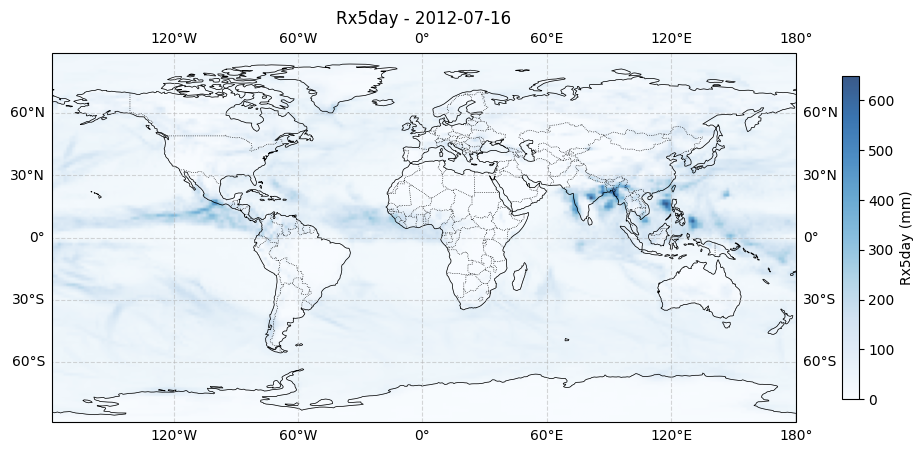

In [18]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from netCDF4 import num2date

#rng = np.random.default_rng(seed=42)
#idx = rng.integers(0, len(dates)) #at random
idx=1950
the_date = dates[idx]
data_img = array[idx, :, :, 0]  

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

im = ax.imshow(data_img, extent=[lon.min(), lon.max(), lat.min(), lat.max()],
               origin='lower', cmap='Blues', alpha=0.8,
               transform=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)  

plt.colorbar(im, label='Rx5day (mm)', shrink=0.7)
ax.set_title(f'Rx5day - {the_date.strftime("%Y-%m-%d")}')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

plt.show()

In [19]:
#print(f"Longitudes min et max : {lon.min():.1f}, {lon.max():.1f}")
#lon_centered = np.where(lon > 180, lon - 360, lon)
#print(lon_centered)
lat_min, lat_max = 41.0, 52.0   
lon_min, lon_max = -5.0, 9.0
lat_indices = np.where((lat >= lat_min) & (lat <= lat_max))[0]
#lon_indices = np.where((lon_centered >= lon_min) & (lon_centered <= lon_max))[0]
lon_indices = np.where((lon >= lon_min) & (lon <= lon_max))[0]
#print(lon_indices)

lat_france = lat[lat_indices]
lon_france = lon[lon_indices]
print(lat_france, "\n", lon_france)

array_fr= array[:, lat_indices, :, :][:, :, lon_indices, :]  # (time, len(lat_indices), len(lon_indices), 1)
print(array_fr.shape)
#8x9, 1980 observations temporelles, 1 variable (Rx5day) -> (1980, 7, 9, 1)



[41.32257587 42.72333486 44.12409297 45.5248501  46.92560615 48.32636102
 49.72711456 51.12786664] 
 [-4.21875 -2.8125  -1.40625  0.       1.40625  2.8125   4.21875  5.625
  7.03125  8.4375 ]
(1980, 8, 10, 1)


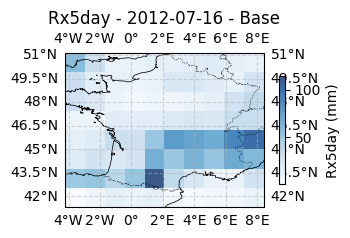

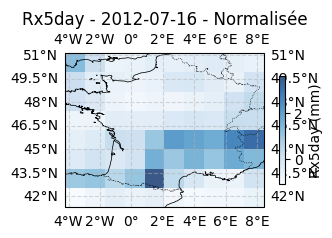

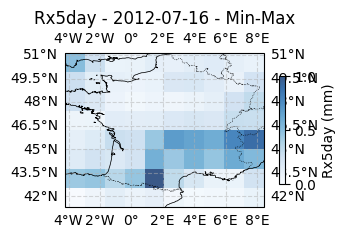

In [20]:
idx=1950
the_date = dates[idx]
img_base = array_fr[idx, :, :, 0]  
m = img_base.mean()
std = img_base.std()
img_norma= (img_base - m) / std

img_min = img_base.min()
img_max = img_base.max()
img_minmax = (img_base - img_min) / (img_max - img_min)

for img in [img_base, img_norma, img_minmax]:
    fig = plt.figure(figsize=(4, 2))
    ax = plt.axes(projection=ccrs.PlateCarree())

    #Ajuster les limites de l'image pour correspondre à la région de la France
    im = ax.imshow(img, extent=[lon_france.min(), lon_france.max(), lat_france.min(), lat_france.max()],
                origin='lower', cmap='Blues', alpha=0.8,
                transform=ccrs.PlateCarree())
    #ax.set_extent([lon_france.min(), lon_france.max(),                lat_france.min(), lat_france.max()],               crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)  

    plt.colorbar(im, label='Rx5day (mm)', shrink=0.7)
    ax.set_title(f'Rx5day - {the_date.strftime("%Y-%m-%d")} - {"Base" if img is img_base else "Normalisée" if img is img_norma else "Min-Max"}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

    plt.show()


# **Analyse exploratoire des données**

In [21]:
#Analyse des distribs ?

# **Variational AutoEncoder (VAE)**

In [22]:
import os
os.environ['KERAS_BACKEND'] = 'torch'
import keras
from keras import layers
from fonction_en_plus.ImagesCallback import ImagesCallback
import sys
import fidle


ModuleNotFoundError: No module named 'modules'

In [ ]:
seed=42
fit_verbosity = 1 #Plus agréable
latent_dim = 12 # et si on gonfle la taille ? 

latent_dim = 4  #4-6: équilibré// 6-12: plus de capacité, mais risque de surapprentissage
#?? faut il +/- de dimension en fonction de la taille ?? Faut il tester plusieurs dimensions ??
#2 if we want to visualize the latent space (harder compression though)

loss_weights  = [1,.06] # 1 Reconstruction loss et 0.06 KL loss (optimize ressemblance) :la tâche de recontsruction est + difficile que la tache de prediction

batch_size    = 4 # On un dataset pas si énorme, augmenter augmenterait perfo ?
epochs        = 8 #On remarque peu d'amélioration après 8 epochs

Q: 
Ne devrait-on pas split le data set selon les saisons pour avoir des résultats corrects ?    
  
R: 
Au contraire, on devrait retrouver une séparation entre les saisons ou les mois dans l'espace latent.   
Il est même possible que certains mois aient  changé de position avec le réchauffement climatique

Q: 
Ne devrait-on pas split le data set selon les saisons pour avoir des résultats corrects ?
---
R: 
Au contraire, on devrait retrouver une séparation entre les saisons ou les mois dans l'espace latent. 
Il est même possible que certains mois aient  changé de position avec le réchauffement climatique

In [ ]:
oups_data = array_fr
#mean = oups_data.mean()
#std = oups_data.std()
#x_data= (oups_data - mean) / std
#pref ?
x_min = oups_data.min()
x_max = oups_data.max()
x_data = (oups_data - x_min) / (x_max - x_min)

#print(x_data.min(), x_data.max())

labels_data= np.array(dates)
print(min(labels_data), max(labels_data), len (labels_data))


1850-01-16 00:00:00 2014-12-16 00:00:00 1980


*Encoder*

In [ ]:
import torch
from torch.distributions.normal import Normal

class Sampling(layers.Layer):
    #Utilise (z_mean, z_log_var) pour échantillonner z, en utilisant la technique de reparamétrisation    
    def call(self, inputs):
        z_mean, z_log_var = inputs

        batch_size,latent_dim = z_mean.shape

        epsilon = Normal(0, 1).sample((batch_size, latent_dim)).to(z_mean.device)
        
        z = z_mean + torch.exp(0.5 * z_log_var) * epsilon 
        return z

In [ ]:
class VAELL (keras.layers.Layer):
   
    def __init__(self, loss_weights=[3,7]):
        super().__init__()
        self.k1 = loss_weights[0]
        self.k2 = loss_weights[1]


    def call(self, inputs):
        k1 = self.k1
        k2 = self.k2
        
        x, z_mean, z_log_var, y = inputs
        
        #Reconstruction loss         
        r_loss = torch.nn.functional.binary_cross_entropy(y, x, reduction='sum')
        
        #KL loss
        kl_loss = - torch.sum(1+ z_log_var - z_mean.pow(2) - z_log_var.exp())
        
        # Total Loss
        loss = r_loss*k1 + kl_loss*k2
        self.add_loss(loss)
        
        return y

    
    def get_config(self):
        return {'loss_weights':[self.k1,self.k2]}
        # To keep track of the loss weights in checkpoints and logs,
        # we need to implement get_config() so that Keras can properly serialize them.

In [ ]:
#?? est-ce qu'il vauydrait mieux une autre architecture ? Trop petit ??

inputs    = keras.Input(shape=(8, 10, 1)) #taille image en entrée
x = layers.Conv2D(16, 3, strides=1, padding="same", activation="relu")(inputs)
x         = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(x)
x         = layers.Flatten()(x)
x         = layers.Dense(64, activation="relu")(x)

#comparaison
#inputs    = keras.Input(shape=(28, 28, 1))
#x         = layers.Conv2D(32, 3, strides=1, padding="same", activation="relu")(inputs)
#x         = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
#x         = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
#x         = layers.Conv2D(64, 3, strides=1, padding="same", activation="relu")(x)
#x         = layers.Flatten()(x)
#x         = layers.Dense(16, activation="relu")(x)

z_mean    = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x) # log or not ?
z         = Sampling()([z_mean, z_log_var])

encoder = keras.Model(inputs, [z_mean, z_log_var, z], name="encoder")

#encoder.summary()

*Decoder*

In [ ]:
inputs  = keras.Input(shape=(latent_dim,))
x       = layers.Dense(4 * 5 * 32, activation="relu")(inputs) #même taille que la dernière couche de l'encoder  
x       = layers.Reshape((4, 5, 32))(x) # reshape objectif : retrouver la taille de la dernière couche de l'encoder pour pouvoir faire du transposed convolution
x       = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
# on force la taille de sortie pour éviter les problèmes de dimension lors du upsampling
#outputs = layers.Conv2DTranspose(1,  3, padding="same", activation="linear")(x)
outputs = layers.Conv2DTranspose(1,  3, padding="same", activation="sigmoid")(x)

#car donnée normalisée, on peut sortir des valeurs négatives, d'où activation linéaire
# our de la génération climatique où l'on veut parfois capturer des événements extrêmes (queues de distribution), 
# linear est souvent plus robuste car elle ne plafonne pas la sortie à 1.

#Comparaoison
#x       = layers.Dense(7 * 7 * 64, activation="relu")(inputs)
#x       = layers.Reshape((7, 7, 64))(x) # reshape ?
#x       = layers.Conv2DTranspose(64, 3, strides=1, padding="same", activation="relu")(x)
#x       = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)
#x       = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
#outputs = layers.Conv2DTranspose(1,  3, padding="same", activation="sigmoid")(x)

decoder = keras.Model(inputs, outputs, name="decoder")

#decoder.summary()

In [ ]:
inputs  = keras.Input(shape=(8, 10, 1))
z_mean, z_log_var, z = encoder(inputs)
outputs              = decoder(z)

# est-ce la meilleur loss pour tester ??

outputs = VAELL(loss_weights=loss_weights)([inputs, z_mean, z_log_var, outputs])

#better to use the custom model architecture ?

vae     = keras.Model(inputs,outputs)

vae.compile(optimizer='adam', loss=None)

In [ ]:
run_dir = '.'

callback_images  = ImagesCallback(x=x_data, z_dim=latent_dim, nb_images=5, from_z=True, from_random=True, run_dir=run_dir)

callbacks_list = [callback_images]


In [ ]:
chrono=fidle.Chrono()
chrono.start()

history = vae.fit(x_data, epochs=epochs, 
                  batch_size=batch_size, 
                  callbacks=callbacks_list, 
                  verbose=fit_verbosity)

chrono.show()

Epoch 1/8
  4/495 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 218.7973   

c:\Users\dan\Gen_AI_ENSAE\.venv\Lib\site-packages\keras\src\backend\common\backend_utils.py:100: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/stepstep - loss: 128.819
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
495/495 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - loss: 114.9087
Epoch 2/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step/step - loss: 108.79
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
495/495 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 108.6402
Epoch 3/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/stepstep - loss: 107.48
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
495/495 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - loss: 107.9922
Epoch 4/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/stepstep - loss: 107.56
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
495/495 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - loss: 107.5611
Epoch 5/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/stepstep - loss: 107.80
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
495/495 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 107.

*Analyse*

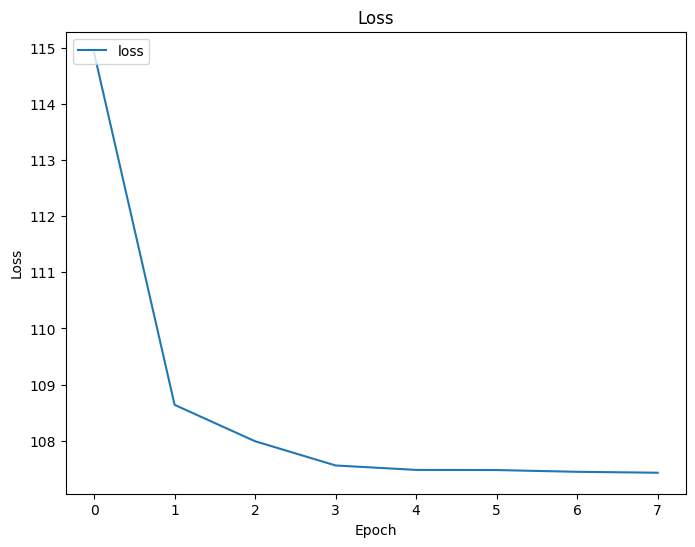

In [ ]:
fidle.scrawler.history(history,  plot={"Loss":['loss']})

# Pas de validation loss possible: pk ?

<br>**Original images :**

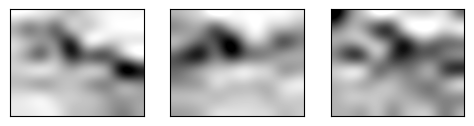

<br>**Encoded/decoded images**

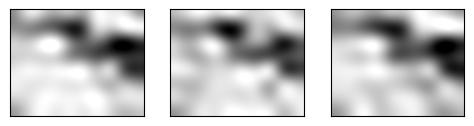

<br>**Generated images from latent space**

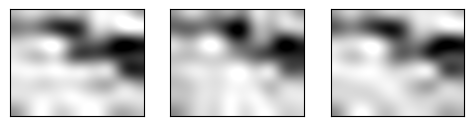

In [ ]:
# meilleur manoère de reconstruire ? plus jolie existerait ?

images_z, images_r = callback_images.get_images( range(0,epochs,2) )

fidle.utils.subtitle('Original images :')
fidle.scrawler.images(x_data[:3], None, indices='all', columns=5, x_size=2,y_size=2)

fidle.utils.subtitle('Encoded/decoded images')
fidle.scrawler.images(images_z[:3], None, indices='all', columns=5, x_size=2,y_size=2)

fidle.utils.subtitle('Generated images from latent space')
fidle.scrawler.images(images_r[:3], None, indices='all', columns=5, x_size=2,y_size=2)

c:\Users\dan\Gen_AI_ENSAE\.venv\Lib\site-packages\keras\src\backend\common\backend_utils.py:100: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


<br>**Originals :**

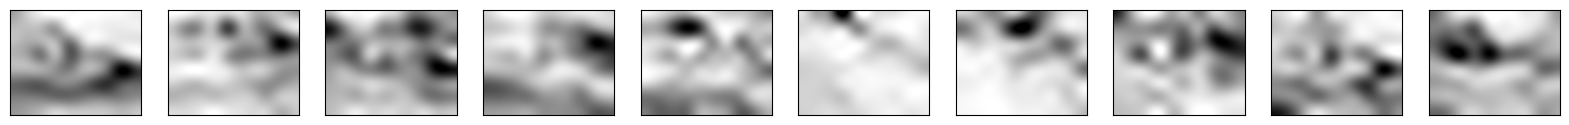

<br>**Reconstructed :**

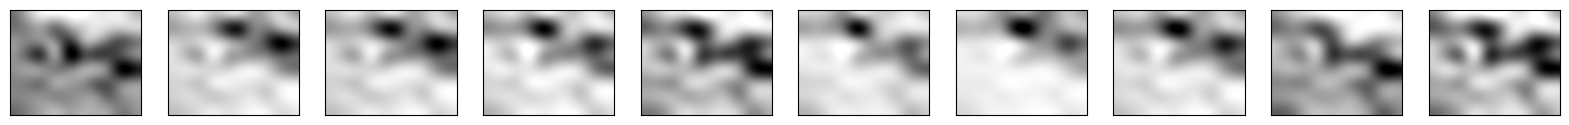

In [ ]:
# ---- Select few images

x_show = fidle.utils.pick_dataset(x_data, n=10)

# ---- Get latent points and reconstructed images

decoder = vae.get_layer('decoder')
encoder = vae.get_layer('encoder')
z_mean, z_var, z = encoder(x_show)
x_reconst = decoder(z)

latent_dim = z.shape[1] # pk ?

# ---- Show it

# Convertir z en numpy avec .detach() pour éviter l'erreur de gradient
labels = [str(np.round(z[i].detach().numpy(), 1)) for i in range(10)]

fidle.utils.subtitle('Originals :')
fidle.scrawler.images(x_show, None, indices='all', columns=10, x_size=2, y_size=2)

fidle.utils.subtitle('Reconstructed :')
# Détacher x_reconst également si nécessaire
fidle.scrawler.images(x_reconst.detach().numpy(), None, indices='all', columns=10, x_size=2, y_size=2)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


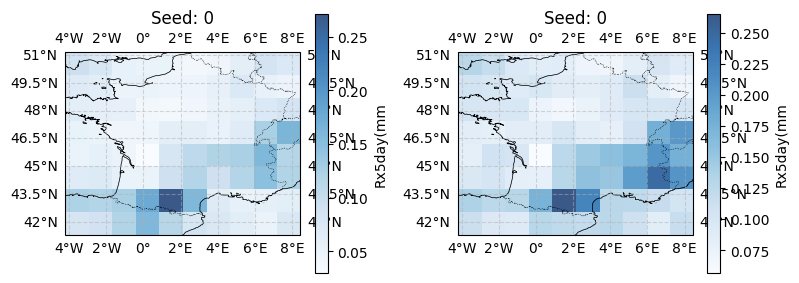

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


c:\Users\dan\Gen_AI_ENSAE\.venv\Lib\site-packages\keras\src\backend\common\backend_utils.py:100: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


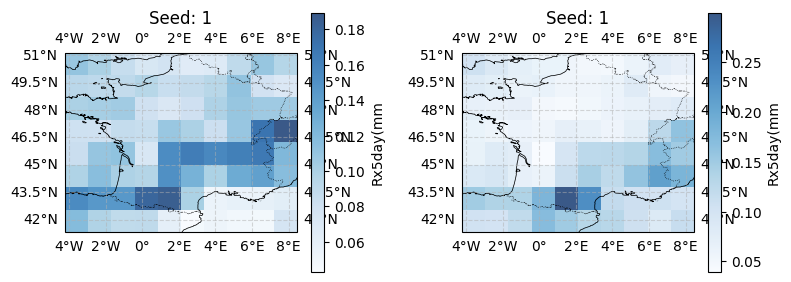

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


c:\Users\dan\Gen_AI_ENSAE\.venv\Lib\site-packages\keras\src\backend\common\backend_utils.py:100: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


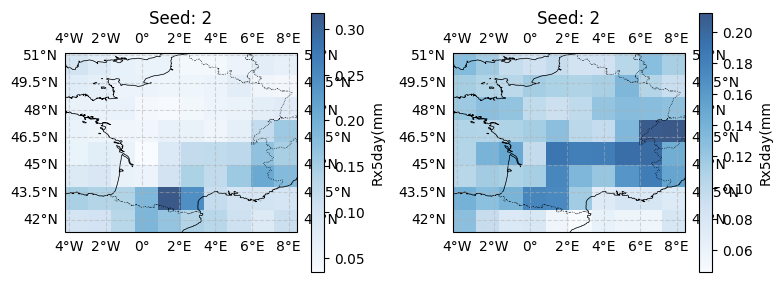

In [ ]:
n = 2
m=3
for i in range(m):
    seed=i
    decoder = vae.get_layer('decoder')
    z_sample = np.random.normal(size=(n, latent_dim))
    imgs = decoder.predict(z_sample)
    fig, axes = plt.subplots(1, n, figsize=(n*4, 4), subplot_kw={'projection': ccrs.PlateCarree()})

    if n == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        image = imgs[i, :, :, 0]

        im = ax.imshow(image,
                    extent=[lon_france.min(), lon_france.max(), lat_france.min(), lat_france.max()],
                    origin='lower', cmap='Blues', alpha=0.8,       
                    transform=ccrs.PlateCarree())

        ax.add_feature(cfeature.LAND,      facecolor='white', edgecolor='black', linewidth=0.5)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS,   linestyle=':', linewidth=0.5)
        ax.add_feature(cfeature.OCEAN,     facecolor='lightblue', alpha=0.3)
        ax.gridlines(draw_labels=True,     linestyle='--', alpha=0.5)

        ax.set_title(f"Seed: {seed}")
        plt.colorbar(im, ax=ax, label='Rx5day(mm', shrink=0.7)

    plt.tight_layout()
    plt.show()



*Espace latent--Visualisation*

In [ ]:
, , z = encoder(x_data, verbose=0)

z_np = z.detach().cpu().numpy() 

df_z = pd.DataFrame(z_np, columns=[f'z{i}' for i in range(z_np.shape[1])])
df_z["month"] = np.array([_.month for _ in labels_data])
df_z["month"] = df_z["month"].astype(str)  

df_z["year"]= np.array([_.year for _ in labels_data])
df_z["year"] = df_z["year"].astype(str) 

months = np.array([_.month for _ in labels_data])
year=np.array([_.year for _ in labels_data])


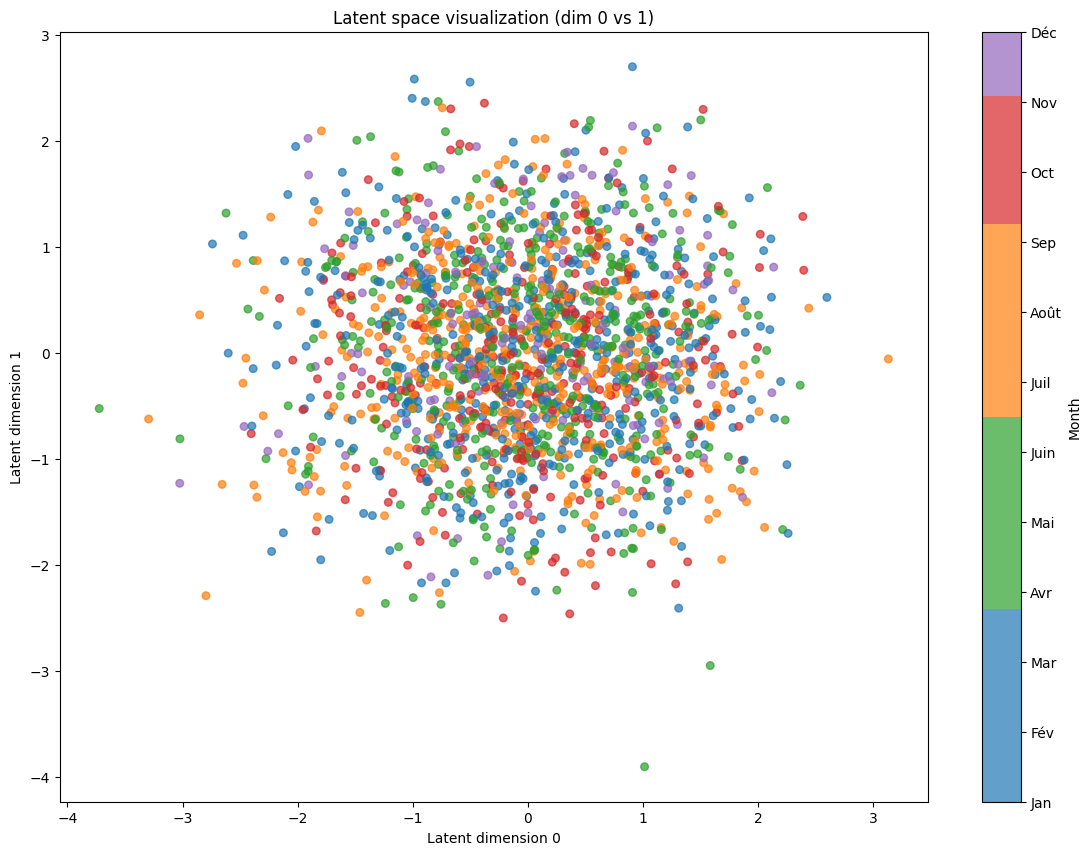

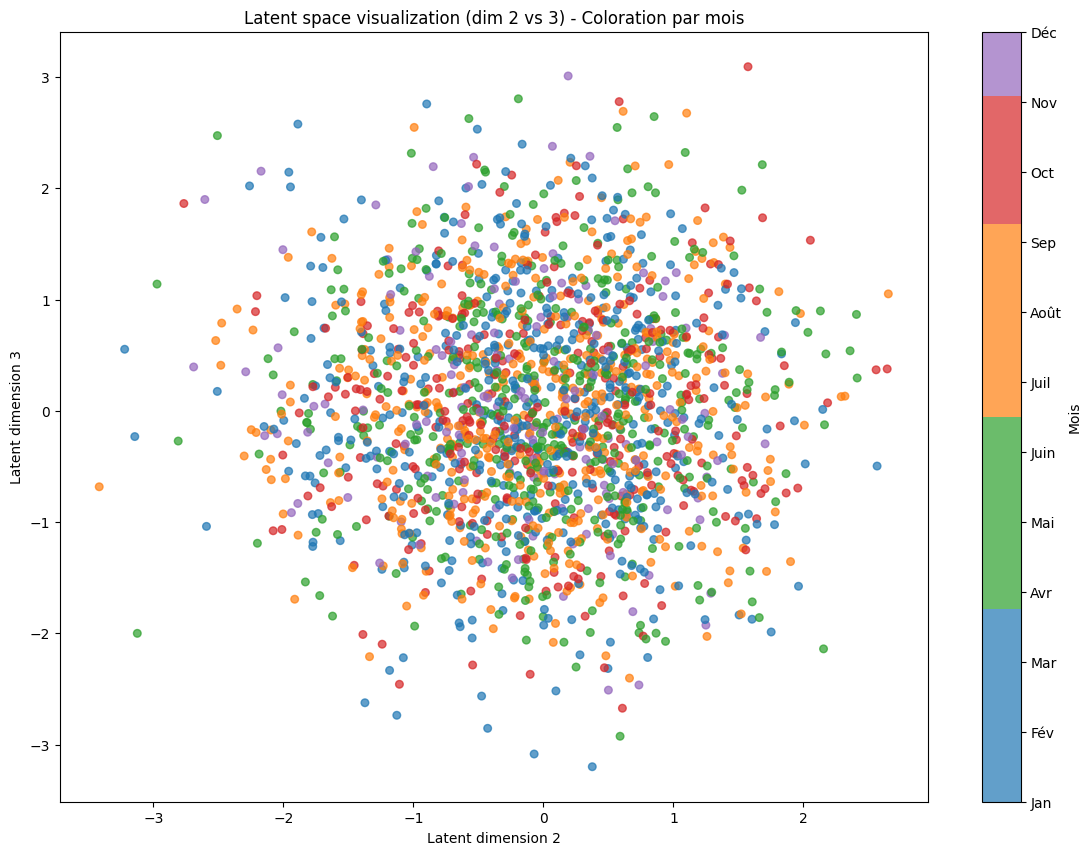

In [ ]:
from matplotlib.colors import ListedColormap

colors = [
    "#1f77b4", "#1f77b4", "#1f77b4",  # Décembre, Janvier, Février (hiver)
    "#2ca02c", "#2ca02c", "#2ca02c",  # Mars, Avril, Mai (printemps)
    "#ff7f0e", "#ff7f0e", "#ff7f0e",  # Juin, Juillet, Août (été)
    "#d62728", "#d62728", "#9467bd"   # Septembre, Octobre, Novembre (automne)
]
cmap_months = ListedColormap(colors)

fig = plt.figure(figsize=(14, 10))
scatter = plt.scatter(z_np[:, 0], z_np[:, 1], c=months-1, cmap=cmap_months, alpha=0.7, s=30)
cbar = plt.colorbar(scatter, label='Month', ticks=range(12))
cbar.set_ticklabels(['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc'])
plt.xlabel('Latent dimension 0')
plt.ylabel('Latent dimension 1')
plt.title('Latent space visualization (dim 0 vs 1)')
plt.show()

fig = plt.figure(figsize=(14, 10))
scatter = plt.scatter(z_np[:, 2], z_np[:, 3], c=months-1, cmap=cmap_months, alpha=0.7, s=30)
cbar = plt.colorbar(scatter, ticks=range(12))
cbar.set_label('Mois')
cbar.set_ticklabels(['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc'])
plt.xlabel('Latent dimension 2')
plt.ylabel('Latent dimension 3')
plt.title('Latent space visualization (dim 2 vs 3) - Coloration par mois')
plt.show()

C:\Users\dan\AppData\Local\Temp\ipykernel_1404\3817465110.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  blues = cm.get_cmap('Blues', 3)
C:\Users\dan\AppData\Local\Temp\ipykernel_1404\3817465110.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  greens = cm.get_cmap('Greens', 3)
C:\Users\dan\AppData\Local\Temp\ipykernel_1404\3817465110.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  reds = cm.get_cmap('YlOrRd', 3)
C:\Users\dan\AppData\Local\Temp\ipyker

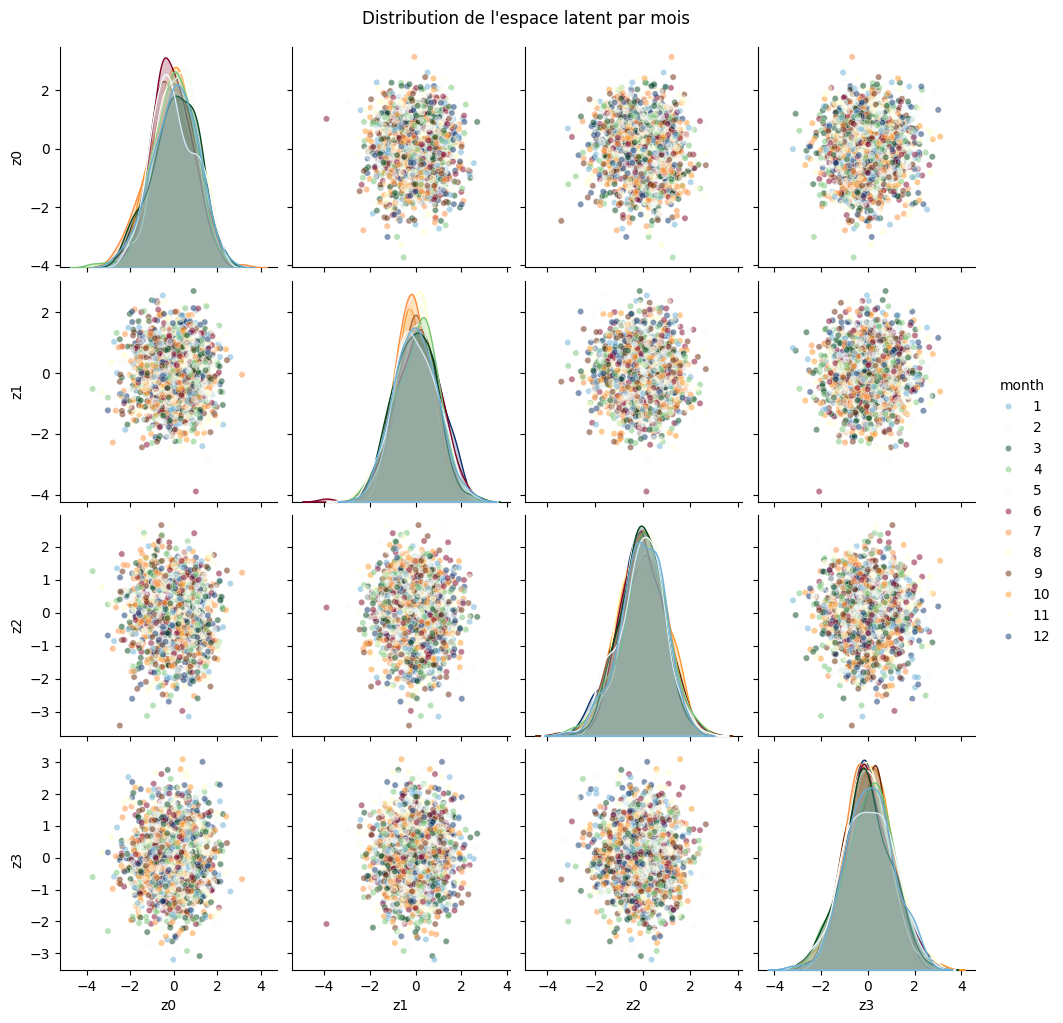

In [ ]:
from matplotlib import cm
import seaborn as sns
#Visualiser comment les images se distribuent dans l'espace latent après encodage
# On essaye de voir si les différentes saisons sont regroupées ou mélangées dans l'espace latent,
# et si certaines dimensions latentes sont plus discriminantes que d'autres pour séparer les saisons.

blues = cm.get_cmap('Blues', 3)   
greens = cm.get_cmap('Greens', 3)   
reds = cm.get_cmap('YlOrRd', 3)      
browns = cm.get_cmap('YlOrBr', 3)

sns.pairplot(df_z, hue="month", palette={'12': blues(0.8),'1': blues(0.5),'2': blues(0.2),
                                       '3': greens(0.8),'4': greens(0.5),'5': greens(0.2),
                                       '6': reds(0.8),'7': reds(0.5),'8': reds(0.2),
                                       '9': browns(0.8),'10': browns(0.5),'11': browns(0.2)},
             plot_kws={'alpha': 0.5, 's': 20})
plt.suptitle('Distribution de l\'espace latent par mois', y=1.02)
plt.show()

#Au cas où, mais pas beau visuellement (ne peut pas désactiver légende)


unique_years = sorted(df_z["year"].unique())
n_years=len(unique_years)
palette = sns.color_palette('Reds', n_colors=n_years)
year_palette = {year: palette[i % len(palette)] for i, year in enumerate(unique_years)}

#sns.pairplot(df_z, hue="year",palette=year_palette,    plot_kws={'alpha': 0.5, 's': 20}, corner=True)
#plt.suptitle("Espace latent par année", y=1.02)
#plt.show()

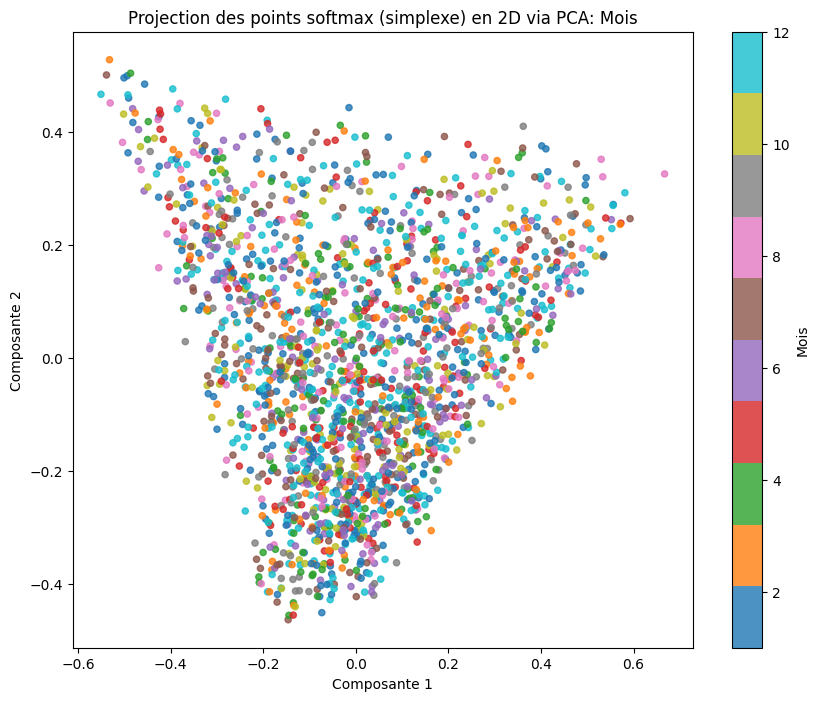

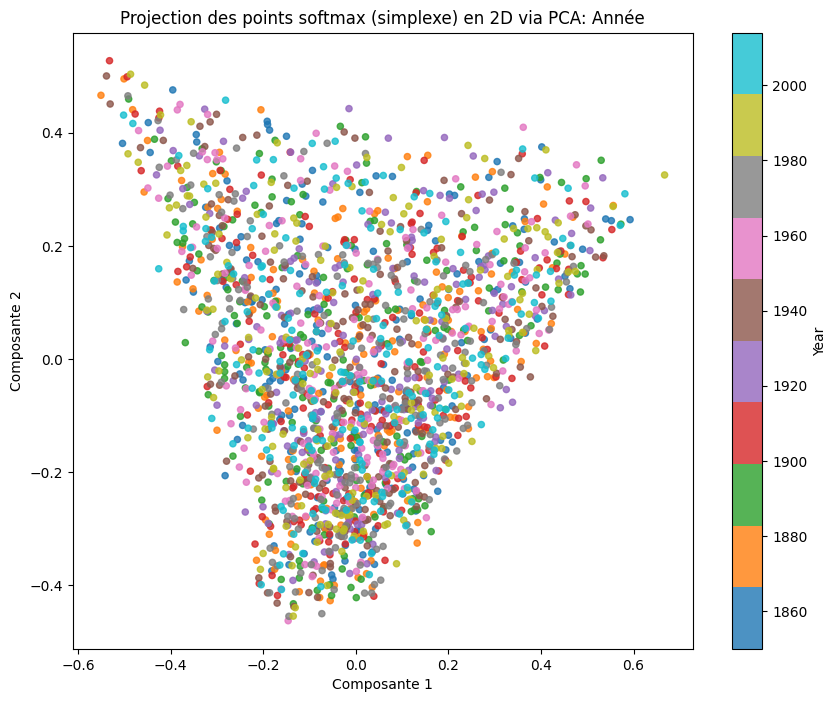

In [ ]:
from sklearn.decomposition import PCA

if latent_dim<4:
    print('Sorry, This part can only work if the latent space is greater than 3')
else:
    #Softmax rescale
    zs = np.exp(z_np)/np.sum(np.exp(z_np),axis=1,keepdims=True)
    pca = PCA(n_components=2)
    zs_2d = pca.fit_transform(zs)


    plt.figure(figsize=(10,8))
    scatter = plt.scatter(zs_2d[:,0], zs_2d[:,1], c=months, cmap='tab10', alpha=0.8, s=20)
    plt.colorbar(scatter, label='Mois')
    plt.title("Projection des points softmax (simplexe) en 2D via PCA: Mois")
    plt.xlabel("Composante 1")
    plt.ylabel("Composante 2")
    plt.show()

    plt.figure(figsize=(10,8))
    scatter = plt.scatter(zs_2d[:,0], zs_2d[:,1], c=year, cmap='tab10', alpha=0.8, s=20)
    plt.colorbar(scatter, label='Year')
    plt.title("Projection des points softmax (simplexe) en 2D via PCA: Année")
    plt.xlabel("Composante 1")
    plt.ylabel("Composante 2")
    plt.show()

# **(GAN))**

In [ ]:
from fonction_en_plus.WGANGP import WGANGP
from fonction_en_plus.DCGAN import DCGAN 
from fonction_en_plus.ImagesCallback_V2 import ImagesCallback_V2

n_critic= 2
num_img       = 12

#useful ?
#x_data = x_data/255 # marche car blanc ou noir
#x_data = x_data.reshape(-1,28,28,1)# reshape 1D-> 2D
#np.random.shuffle(x_data)

ModuleNotFoundError: No module named 'modules'

**Discriminator**

In [ ]:
#leakyRelu pour améliorer cv opti
#strides 2 au lieu de maxpooling
#  sigmoid to get output in [0,1] range (because of the normalization of the input images)
# pk préciser pente LeakyRelu ?
# Stride = 2 to downsample
# padding = "same" to keep the output size the same as input size
# (except for the last layer)
#augmente kernel_size-> picture + grande ?

#?? est-ce qu'il vauydrait mieux une autre architecture ? Trop petit ??


*DCGAN*

In [ ]:
inputs    = keras.Input(shape=(8, 10, 1)) #taille image en entrée
x = layers.Conv2D(16, kernel_size=3, strides=1, padding="same")(inputs)
x       = layers.LeakyReLU(alpha=0.2)(x)
x         = layers.Conv2D(32, 3, strides=2, padding="same")(x)
x       = layers.LeakyReLU(alpha=0.2)(x)

x         = layers.Flatten()(x)
x       = layers.Dropout(0.2)(x) 
z       = layers.Dense(1, activation="sigmoid")(x) 

discriminator = keras.Model(inputs, z, name="discriminator")
#discriminator.summary()

#Comparaison
#inputs  = keras.Input(shape=(28, 28, 1))
#x       = layers.Conv2D(64, kernel_size=4, strides=2, padding="same")(inputs)
#x       = layers.LeakyReLU(alpha=0.2)(x)
#x       = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
#x       = layers.LeakyReLU(alpha=0.2)(x)
#x       = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
#x       = layers.LeakyReLU(alpha=0.2)(x)

c:\Users\dan\Gen_AI_ENSAE\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


*WGANGP*

In [ ]:
inputs    = keras.Input(shape=(8, 10, 1)) #taille image en entrée
x = layers.Conv2D(16, kernel_size=3, strides=1, padding="same")(inputs)
x       = layers.LeakyReLU(alpha=0.2)(x)
x         = layers.Conv2D(32, 3, strides=2, padding="same")(x)
x       = layers.LeakyReLU(alpha=0.2)(x)

x         = layers.Flatten()(x)
x       = layers.Dropout(0.2)(x) 
z       = layers.Dense(1)(x) 

discriminator_wg = keras.Model(inputs, z, name="discriminator_wg")
#discriminator.summary()

#Comparaison
#inputs  = keras.Input(shape=(28, 28, 1))
#x       = layers.Conv2D(64, kernel_size=4, strides=2, padding="same")(inputs)
#x       = layers.LeakyReLU(alpha=0.2)(x)
#x       = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
#x       = layers.LeakyReLU(alpha=0.2)(x)
#x       = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
#x       = layers.LeakyReLU(alpha=0.2)(x)

**Generator** : Same DCGAN & WGANGP

In [ ]:
inputs  = keras.Input(shape=(latent_dim,))
x       = layers.Dense(4 * 5 * 32)(inputs) 
x       = layers.Reshape((4, 5, 32))(x)
x       = layers.UpSampling2D()(x)
x         = layers.Conv2D(32, 3, strides=1, padding="same", activation='relu')(x)
x       = layers.UpSampling2D()(x)
x         = layers.Conv2D(64, 3, strides=2, padding="same", activation='relu')(x)
outputs = layers.Conv2D(1,    kernel_size=5, strides=1, padding="same", activation="sigmoid")(x)

generator = keras.Model(inputs, outputs, name="generator")
#generator.summary()

#Comparaison
#x       = layers.Dense(7 * 7 * 64)(inputs)
#x       = layers.Reshape((7, 7, 64))(x)
#x       = layers.UpSampling2D()(x)
#x       = layers.Conv2D(128,  kernel_size=3, strides=1, padding='same', activation='relu')(x)
#x       = layers.UpSampling2D()(x)
#x       = layers.Conv2D(256,  kernel_size=3, strides=1, padding='same', activation='relu')(x)
#outputs = layers.Conv2D(1,    kernel_size=5, strides=1, padding="same", activation="sigmoid")(x)

In [ ]:
gan = DCGAN(discriminator=discriminator, generator=generator, latent_dim=latent_dim)

gan_wg = WGANGP(discriminator_wg=discriminator_wg, generator=generator, latent_dim=latent_dim, n_critic=n_critic)

Fidle DCGAN is ready :-)  latent dim = 4


In [ ]:
gan.compile(
    discriminator_optimizer = keras.optimizers.Adam(learning_rate=0.0001),
    generator_optimizer     = keras.optimizers.Adam(learning_rate=0.0001),
    loss_function           = keras.losses.BinaryCrossentropy(),
)

gan_wg.compile(
#     discriminator_optimizer = keras.optimizers.Adam(learning_rate=0.0001),
#     generator_optimizer     = keras.optimizers.Adam(learning_rate=0.0001)
    discriminator_optimizer_wg = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5, beta_2=0.9),
    generator_optimizer_wg     = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5, beta_2=0.9)
)

In [ ]:
run_dir = '.'
imagesCallback = ImagesCallback(num_img=12, latent_dim=latent_dim, run_dir=f'{run_dir}/images')


In [ ]:
history = gan.fit( x_data, 
                   epochs=epochs, 
                   batch_size=batch_size, 
                   callbacks=[imagesCallback], 
                   verbose=fit_verbosity )

TypeError: ImagesCallback.__init__() got an unexpected keyword argument 'num_img'

In [ ]:
history_wg = gan_wg.fit( x_data, 
                   epochs=epochs, 
                   batch_size=batch_size, 
                   callbacks=[imagesCallback], 
                   verbose=fit_verbosity )

In [ ]:
fidle.scrawler.history(history,  plot={'loss':['d_loss','g_loss']})

fidle.scrawler.history(history_wg,  plot={'loss':['d_loss','g_loss']})

In [ ]:
images=[]
for epoch in range(0,epochs,1):
    for i in range(num_img):
        filename = f'{run_dir}/images/image-{epoch:03d}-{i:02d}.jpg'
        image    = io.imread(filename)
        images.append(image)      

fidle.scrawler.images(images, None, indices='all', columns=num_img, x_size=1,y_size=1, interpolation=None, y_padding=0, spines_alpha=0)

nb_images = 12*15

z = np.random.normal(size=(nb_images,latent_dim))
images = gan.predict(z, verbose=0)

fidle.scrawler.images(images, None, indices='all', columns=num_img, x_size=1,y_size=1, interpolation=None, y_padding=0, spines_alpha=0)

images=[]
for epoch in range(0,epochs,1):
    for i in range(num_img):
        filename = f'{run_dir}/images/image-{epoch:03d}-{i:02d}.jpg'
        image    = io.imread(filename)
        images.append(image)      

fidle.scrawler.images(images, None, indices='all', columns=num_img, x_size=1,y_size=1, interpolation=None, y_padding=0, spines_alpha=0, save_as='04-learning')

nb_images = 12*15

z = np.random.normal(size=(nb_images,latent_dim))
images = gan_wg.predict(z, verbose=0)

fidle.scrawler.images(images, None, indices='all', columns=num_img, x_size=1,y_size=1, interpolation=None, y_padding=0, spines_alpha=0, save_as='04-learning')
